# Spindown, 2026-09-09

The rotor was driven up by a swept three-phase field, then left to coast. Drive off at **front-end GPS 1473030703**. It kept turning for **97 minutes** before being captured into libration.

This is the high-rate, long-decay spindown that 2026-09-08 could not provide. That run managed 23.5% decay from 0.172 Hz over 616 s and could not separate the two damping models; the notebook for it said so explicitly and asked for exactly this measurement.

**The question:** is the decay *exponential* (viscous drag, torque ∝ ω) or *linear* (constant retarding torque)? It sets whether there is a terminal speed at all.

| | drag at 15 Hz | terminal speed |
|---|---|---|
| viscous | 0.91 × stator torque | ~16.5 Hz |
| constant torque | 0.009 × | no drag limit |

---

### ⚠ The divisor: rotation = dominant LES line ÷ 4

This is the single most error-prone step and it is not discoverable from the spectrum alone.

**The LES looks at the sail, not the rotor body.** The sail is a bar across the rotor, so it is **2-fold** — the same silhouette twice per revolution. The LES fundamental is therefore 2 × f_rot, and its second harmonic (**4 × f_rot**) is the strongest line in the spectrum.

Spectroscopy *cannot* settle this on its own: a 1-fold feature at f and a 2-fold feature at f/2 produce identical line sets. The tie was broken by **timing the rotor by eye**, twice, ~12 min apart — 7–8 s and then ~9 s per revolution — both matching the ÷4 reading and its predicted decay, and both ruling out ÷2 (which would have given 4.6 s).

Note the divisor is **different for libration**: there the LES rectifies (responds to |θ|, one cycle per one-way swing), so libration = line ÷ 2. Two different factors of two, on the same channel, for two unrelated reasons. §7 handles the change at capture.

### Method notes carried over from 2026-09-08

1. **Use `LES_YAW_IN1_DQ`, not `OUT_DQ`** — tapped upstream of every switch, so it records regardless of the drive configuration.
2. **Never take the loudest peak as the fundamental.** Follow a chosen line in a band that tracks the previous estimate, and check sub-harmonics explicitly.

In [1]:
import numpy as np, matplotlib.pyplot as plt, os, h5py, subprocess
from scipy.signal import spectrogram, decimate, welch
from scipy.stats import kurtosis, skew

# Canonical data: .h5 written by lab_utils/batch_fetch.py, archived to Dropbox
# in the standard convention. Looked for locally first, then pulled by rclone.
GPS_A, GPS_B = 1473029300, 1473037100
STOP    = 1473030703          # front-end GPS at drive-off
DRIVE_ON = 1473029513         # sweep drive reached full amplitude
DIVISOR  = 4.0                # dominant LES line -> rotation (2-fold sail)

WANT = {'les': ('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw'),
        'drv': ('Y1_RDS-OUTS_V2_OUT_DQ', 'Electrodes')}
SEARCH = ['../lab_utils/data', 'data', '.']

def get_h5(stem, dropbox_sub):
    fn = f'{stem}_{GPS_A}_{GPS_B}.h5'
    for d in SEARCH:
        p = os.path.join(d, fn)
        if os.path.exists(p):
            return p
    os.makedirs('data', exist_ok=True)
    src = f'dropbox:Microspheres/TFINER/data/{dropbox_sub}/{fn}'
    print(f'fetching {fn} from Dropbox...')
    subprocess.run(['rclone', 'copyto', src, f'data/{fn}'], check=True)
    return f'data/{fn}'

def load(path):
    """Return (samples, gps_of_each_sample, fs).

    batch_fetch drops NaN gaps and records where each contiguous run starts in
    /segments, so build the time axis from that rather than assuming one
    unbroken block -- a DAQ dropout would otherwise shift every timestamp.
    """
    with h5py.File(path, 'r') as f:
        y  = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s  = f['segments']
        t  = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

les, t_les, fs = load(get_h5(*WANT['les']))
drv, t_drv, _  = load(get_h5(*WANT['drv']))
assert np.allclose(t_les, t_drv), 'LES and drive time axes differ'
t = t_les - STOP               # seconds relative to drive-off
print(f'{len(les)/fs:.0f} s at {fs:.0f} Hz')
print(f't = {t[0]:.0f} .. {t[-1]:.0f} s relative to drive-off '
      f'({(t[-1]-t[0])/3600:.2f} h total)')

/tmp/ipykernel_1315453/2045271308.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.signal import spectrogram, decimate, welch


7800 s at 1024 Hz
t = -1403 .. 6397 s relative to drive-off (2.17 h total)


## 1. The drive: sweep up, then off

The rotor was spun up by sweeping `f_elec` from 0.3 to 4.0 Hz in 75 steps of 15 s. With m = 8 that commands a rotor rate of 0.0375 → 0.500 Hz.

Confirm where the drive actually starts and stops from the electrode signal itself, rather than trusting the log.

drive amplitude 4661 counts rms (6400/sqrt(2) = 4525 -> unclipped at the module)
drive ON  t = -1143 s  (GPS 1473029560)
drive OFF t = +2 s  (GPS 1473030705)
duration  1145 s


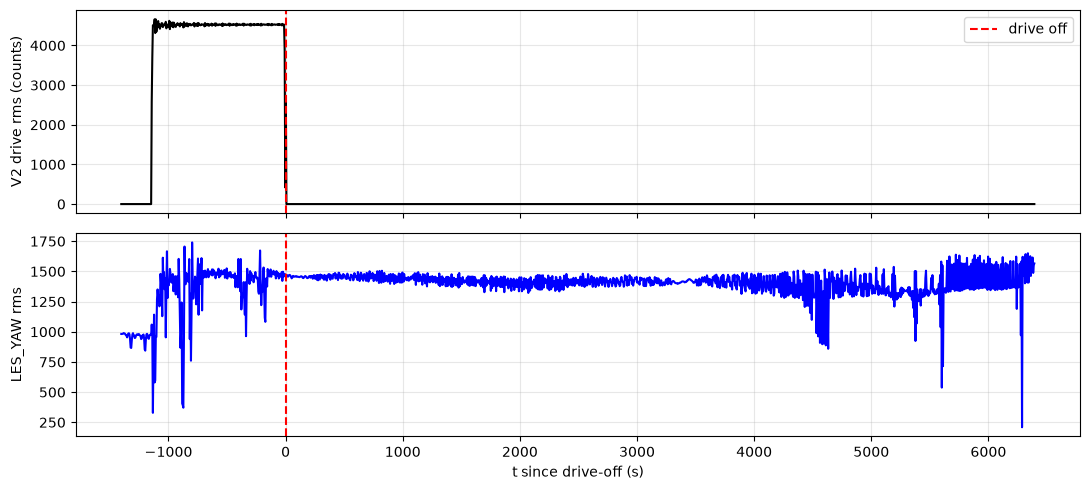

In [2]:
blk = int(5*fs)
n = len(drv)//blk
tb = np.array([t[i*blk] for i in range(n)])
rms = np.array([drv[i*blk:(i+1)*blk].std() for i in range(n)])

on = rms > 500
i0, i1 = np.argmax(on), len(on)-1-np.argmax(on[::-1])
print(f'drive amplitude {rms[on].max():.0f} counts rms '
      f'(6400/sqrt(2) = {6400/np.sqrt(2):.0f} -> unclipped at the module)')
print(f'drive ON  t = {tb[i0]:+.0f} s  (GPS {STOP+tb[i0]:.0f})')
print(f'drive OFF t = {tb[i1]:+.0f} s  (GPS {STOP+tb[i1]:.0f})')
print(f'duration  {tb[i1]-tb[i0]:.0f} s')

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(tb, rms, 'k-'); ax[0].set_ylabel('V2 drive rms (counts)')
ax[0].axvline(0, color='r', ls='--', label='drive off'); ax[0].legend()
lb = np.array([les[i*blk:(i+1)*blk].std() for i in range(n)])
ax[1].plot(tb, lb, 'b-'); ax[1].set_ylabel('LES_YAW rms'); ax[1].set_xlabel('t since drive-off (s)')
ax[1].axvline(0, color='r', ls='--')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Spectrogram — the rotation line and where it dies

The line should fall smoothly after drive-off and then break up at capture.

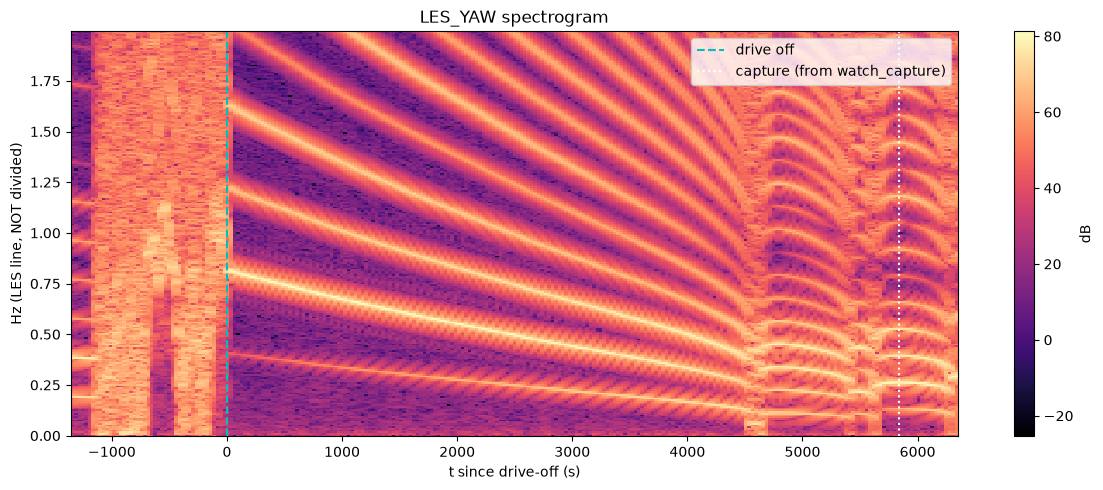

In [3]:
# decimate to 16 Hz -- rotation lines are all below 4 Hz
y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
f_, t_, S = spectrogram(y16, fs16, nperseg=int(120*fs16), noverlap=int(90*fs16))
t_rel = t_ + t[0]
m = f_ < 2.0
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_rel, f_[m], 10*np.log10(S[m]+1e-12), shading='auto', cmap='magma')
plt.axvline(0, color='c', ls='--', lw=1.5, label='drive off')
plt.axvline(5842, color='w', ls=':', lw=1.5, label='capture (from watch_capture)')
plt.ylabel('Hz (LES line, NOT divided)'); plt.xlabel('t since drive-off (s)')
plt.colorbar(label='dB'); plt.legend(loc='upper right'); plt.title('LES_YAW spectrogram')
plt.tight_layout(); plt.show()

## 3. Establish the divisor

Two checks, both of which must pass before any rate below is meaningful.

**(a) Harmonic series.** If rotation is `line/4`, then *every* multiple of `line/4` should be present, with even multiples stronger (the sail is 2-fold, so odd ones come only from its slight asymmetry).

**(b) Sub-harmonic exclusion.** Test candidate fundamentals explicitly. The degeneracy between "1-fold at f" and "2-fold at f/2" is real and the spectrum cannot break it — that is what the eye timing was for, recorded in the header.

In [4]:
# Take a clean stretch just after drive-off where the line is strong.
seg = (t > 10) & (t < 250)
ys = decimate(decimate(les[seg]-les[seg].mean(), 8, ftype='fir'), 8, ftype='fir')
fw, Pw = welch(ys, fs16, nperseg=len(ys), noverlap=0); dfw = fw[1]-fw[0]

def amp_at(f0, hw=0.010):
    mm = (fw > f0-hw) & (fw < f0+hw)
    return np.sqrt(2*Pw[mm].sum()*dfw) if mm.any() else 0.0

mm = (fw > 0.05) & (fw < 3.0)
line0 = fw[mm][np.argmax(Pw[mm])]
f_rot0 = line0/DIVISOR
print(f'dominant line {line0:.4f} Hz  ->  rotation {f_rot0:.4f} Hz '
      f'({1/f_rot0:.2f} s per turn)\n')

print(f'{"k":>3} {"k*f_rot":>9} {"amp":>10}  parity')
ev, od = [], []
for k in range(1, 11):
    a_ = amp_at(f_rot0*k)
    (ev if k % 2 == 0 else od).append(a_)
    bar = '#'*int(46*a_/max(amp_at(f_rot0*4), 1e-9))
    print(f'{k:3d} {f_rot0*k:9.4f} {a_:10.1f}  {"even" if k%2==0 else "odd ":>4} |{bar}')
print(f'\neven/odd power ratio = {sum(ev)/max(sum(od),1e-9):.2f}'
      '   (>1 confirms a 2-fold feature)')

print('\nsub-harmonic exclusion -- is there power BELOW the claimed fundamental?')
for d in (1, 2, 4, 8):
    print(f'   line/{d:<2d} = {line0/d:7.4f} Hz   amp {amp_at(line0/d):9.1f}')
print('\nNOTE: line/4 and line/8 being weak does not by itself prove the')
print('fundamental -- a perfectly symmetric feature emits nothing there.')
print('The eye timing (7-8 s then ~9 s, 12 min apart) is what fixes it.')

dominant line 0.7958 Hz  ->  rotation 0.1990 Hz (5.03 s per turn)

  k   k*f_rot        amp  parity
  1    0.1990        1.4  odd  |
  2    0.3979       30.9  even |
  3    0.5969        1.2  odd  |
  4    0.7958     1628.5  even |##############################################
  5    0.9948        0.8  odd  |
  6    1.1937      374.2  even |##########
  7    1.3927        0.6  odd  |
  8    1.5917      572.1  even |################
  9    1.7906        0.5  odd  |
 10    1.9896       80.5  even |##

even/odd power ratio = 593.40   (>1 confirms a 2-fold feature)

sub-harmonic exclusion -- is there power BELOW the claimed fundamental?
   line/1  =  0.7958 Hz   amp    1628.5
   line/2  =  0.3979 Hz   amp      30.9
   line/4  =  0.1990 Hz   amp       1.4
   line/8  =  0.0995 Hz   amp       2.2

NOTE: line/4 and line/8 being weak does not by itself prove the
fundamental -- a perfectly symmetric feature emits nothing there.
The eye timing (7-8 s then ~9 s, 12 min apart) is what fixes it.


## 4. Track the rotation frequency

Band-following peak tracker with parabolic sub-bin interpolation, on the **dominant (4×) line**, divided by 4.

Sub-bin interpolation matters here: a bare FFT bin at these window lengths is ~0.008 Hz, and the exponential-vs-linear difference we are trying to resolve is of that order. Without interpolation the fit compares quantization noise.

In [5]:
def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

WIN, STEP = 150.0, 60.0          # s per estimate, s between estimates
nw, sw = int(WIN*fs16), int(STEP*fs16)
t16 = t[0] + np.arange(len(y16))/fs16

rows = []
track = line0
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    if tc < 10: continue          # skip the drive and the ramp-down
    fpk, snr = peak_in_band(y16[i:i+nw], fs16, track*0.80, track*1.15)
    if np.isnan(fpk): continue
    blkk = y16[i:i+nw]
    rows.append((tc, fpk, fpk/DIVISOR, snr, blkk.std(),
                 kurtosis(blkk), skew(blkk)))
    track = fpk

T    = np.array([r[0] for r in rows]); LINE = np.array([r[1] for r in rows])
FR   = np.array([r[2] for r in rows]); SNR  = np.array([r[3] for r in rows])
RMS  = np.array([r[4] for r in rows]); KURT = np.array([r[5] for r in rows])
SKW  = np.array([r[6] for r in rows])
print(f'{len(T)} estimates, t = {T[0]:.0f} .. {T[-1]:.0f} s')
print(f'{"t (s)":>8} {"line":>9} {"rotor":>9} {"turn s":>8} {"SNR":>7} {"kurt":>7} {"rms":>7}')
for k in range(0, len(T), max(1, len(T)//25)):
    print(f'{T[k]:8.0f} {LINE[k]:9.4f} {FR[k]:9.5f} {1/FR[k]:8.2f} '
          f'{SNR[k]:7.1f} {KURT[k]:+7.3f} {RMS[k]:7.0f}')

105 estimates, t = 52 .. 6292 s
   t (s)      line     rotor   turn s     SNR    kurt     rms
      52    0.8107   0.20268     4.93   493.5  -1.418    1462
     292    0.7731   0.19328     5.17  2097.3  -1.425    1453
     532    0.7395   0.18488     5.41  1982.4  -1.427    1459
     772    0.7057   0.17644     5.67  1685.8  -1.428    1458
    1012    0.6728   0.16820     5.95  1172.3  -1.431    1448
    1252    0.6412   0.16030     6.24  1777.4  -1.433    1435
    1492    0.6122   0.15306     6.53  1942.0  -1.433    1422
    1732    0.5827   0.14567     6.86  1331.9  -1.433    1413
    1972    0.5555   0.13887     7.20  1088.6  -1.436    1404
    2212    0.5281   0.13203     7.57  1144.3  -1.435    1415
    2452    0.5010   0.12525     7.98  1431.6  -1.434    1432
    2692    0.4743   0.11857     8.43  1081.5  -1.431    1426
    2932    0.4491   0.11227     8.91  1245.7  -1.431    1431
    3172    0.4244   0.10611     9.42   926.3  -1.429    1416
    3412    0.3989   0.09972    10.03 

## 5. Which points are trustworthy?

Three criteria. The third is new for this run and is the one that matters most.

- **SNR** — once the line dies the tracker still returns whatever is loudest.
- **Monotonic** — a freely decaying rotor cannot speed up. Any upward step means the tracker jumped.
- **State** — the rotor is only *rotating* for part of this record. After capture the same tracker returns a perfectly plausible number that is a **libration** frequency, on a **different divisor**. Including those points in a spindown fit is meaningless.

State is judged on **waveform shape**, not frequency: a rotating rotor projects as a sinusoid (kurtosis ≈ −1.43), a librating one folds about its turning points and cusps (kurtosis ≈ +0.9 at large amplitude).

⚠ **This discriminator is not reliable at small libration amplitude** — a small-amplitude libration is itself near-sinusoidal, so kurtosis returns toward −1.5 and the test can read "rotating" again. It is used here only to find the *first* transition, which is well-determined; late-record labels are not trusted.

74 of 105 points kept
kept t = 52 .. 4432 s (73.0 min)
frequency 0.20268 -> 0.06835 Hz (66.3% decay)


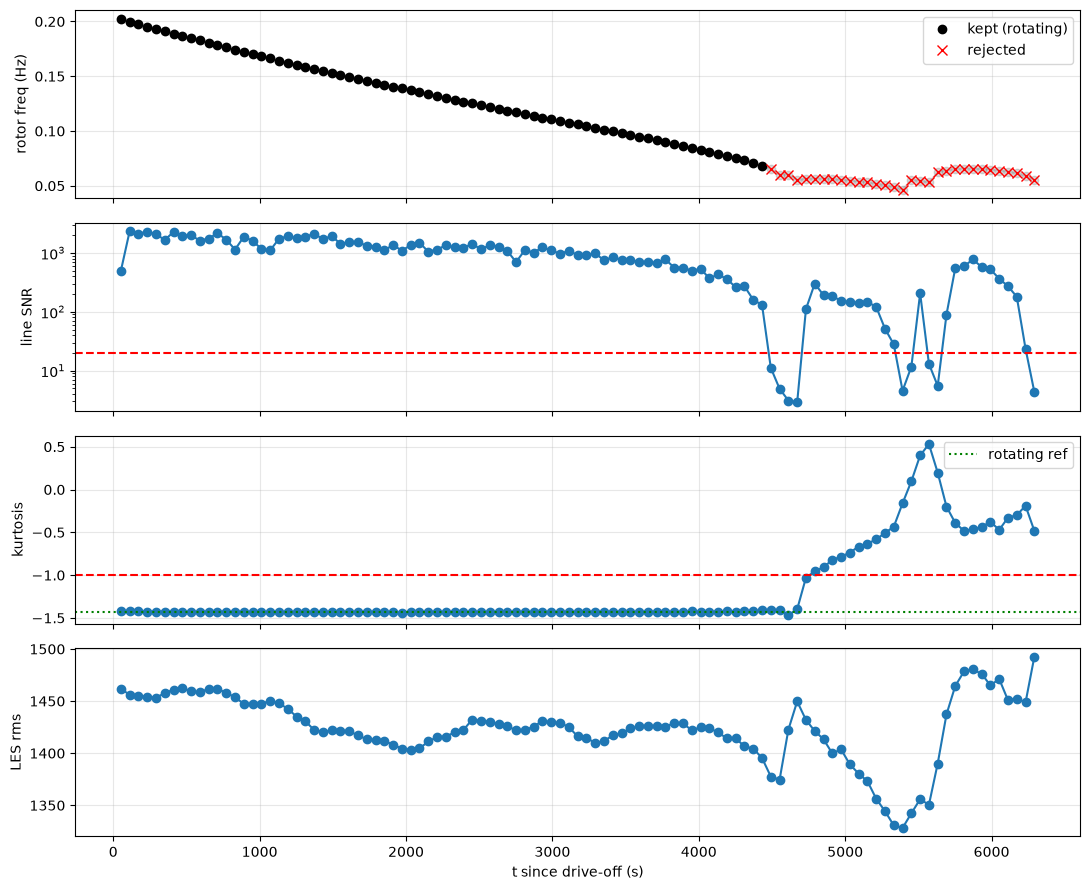

In [6]:
SNR_MIN  = 20.0
KURT_ROT = -1.0          # comfortably inside the rotating population (~-1.43)
MAX_SKIP = 3             # consecutive low-SNR points tolerated before giving up

good = np.zeros(len(FR), bool)
start = int(np.argmax(SNR > SNR_MIN))
runmin, capture_i, skips = np.inf, None, 0
for k in range(start, len(FR)):
    if SNR[k] <= SNR_MIN:
        # A brief SNR dropout is not the end of the rotation -- the line
        # recovers. Skip the point instead of ending the record, but give up
        # if they run together.
        skips += 1
        if skips > MAX_SKIP:
            break
        continue
    skips = 0
    if KURT[k] > KURT_ROT:                 # no longer sinusoidal -> capturing
        capture_i = k
        break
    if FR[k] > runmin*1.02:                # sped up -> tracker lost the line
        break
    good[k] = True
    runmin = min(runmin, FR[k])

print(f'{good.sum()} of {len(good)} points kept')
print(f'kept t = {T[good].min():.0f} .. {T[good].max():.0f} s '
      f'({(T[good].max()-T[good].min())/60:.1f} min)')
print(f'frequency {FR[good].max():.5f} -> {FR[good].min():.5f} Hz '
      f'({100*(1-FR[good].min()/FR[good].max()):.1f}% decay)')
if capture_i is not None:
    print(f'\nrotation ends at t = {T[capture_i]:.0f} s '
          f'({T[capture_i]/60:.1f} min), kurtosis {KURT[capture_i]:+.3f}')

fig, ax = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
ax[0].plot(T, FR, 'o-', alpha=.3, color='gray')
ax[0].plot(T[good], FR[good], 'ko', label='kept (rotating)')
ax[0].plot(T[~good], FR[~good], 'rx', ms=7, label='rejected')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend()
ax[1].semilogy(T, SNR, 'o-'); ax[1].axhline(SNR_MIN, color='r', ls='--'); ax[1].set_ylabel('line SNR')
ax[2].plot(T, KURT, 'o-'); ax[2].axhline(KURT_ROT, color='r', ls='--')
ax[2].axhline(-1.43, color='g', ls=':', label='rotating ref'); ax[2].set_ylabel('kurtosis'); ax[2].legend()
ax[3].plot(T, RMS, 'o-'); ax[3].set_ylabel('LES rms'); ax[3].set_xlabel('t since drive-off (s)')
for a in ax:
    a.grid(alpha=.3)
    if capture_i is not None: a.axvline(T[capture_i], color='m', ls='-.', alpha=.7)
plt.tight_layout(); plt.show()

## 6. Exponential vs linear

This is what the run was for.

EXPONENTIAL  tau =   72.5 min   f0 = 0.21351 Hz   residual 3.6872 mHz
LINEAR       -0.0293 mHz/s   f0 = 0.19880 Hz   residual 1.8491 mHz

ratio of residuals (linear/exponential) = 0.501
  < 1 favours linear (constant torque); > 1 favours exponential (viscous)

2026-09-08 gave tau = 36.8 min and favoured LINEAR at every cutoff tried.
That run had 23.5% decay tracked on a mis-identified line; this one has 66%.


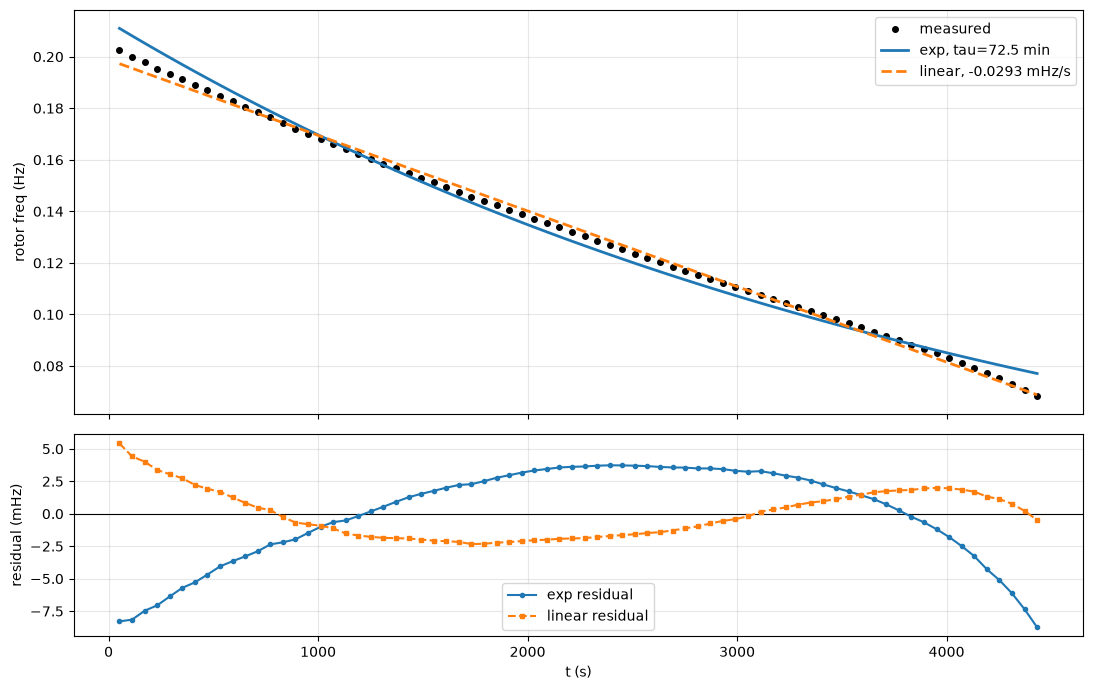

In [7]:
tg, fg = T[good], FR[good]
pe = np.polyfit(tg, np.log(fg), 1); tau = -1/pe[0]; f0e = np.exp(pe[1])
fit_e = f0e*np.exp(-tg/tau)
pl = np.polyfit(tg, fg, 1); fit_l = np.polyval(pl, tg)
rms_e = np.sqrt(np.mean((fg-fit_e)**2)); rms_l = np.sqrt(np.mean((fg-fit_l)**2))

print(f'EXPONENTIAL  tau = {tau/60:6.1f} min   f0 = {f0e:.5f} Hz   residual {rms_e*1e3:.4f} mHz')
print(f'LINEAR       {pl[0]*1e3:7.4f} mHz/s   f0 = {pl[1]:.5f} Hz   residual {rms_l*1e3:.4f} mHz')
print(f'\nratio of residuals (linear/exponential) = {rms_l/rms_e:.3f}')
print('  < 1 favours linear (constant torque); > 1 favours exponential (viscous)')
print(f'\n2026-09-08 gave tau = 36.8 min and favoured LINEAR at every cutoff tried.')
print(f'That run had 23.5% decay tracked on a mis-identified line; this one has '
      f'{100*(1-fg.min()/fg.max()):.0f}%.')

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={'height_ratios':[2,1]})
ax[0].plot(tg, fg, 'ko', ms=4, label='measured')
ax[0].plot(tg, fit_e, '-',  lw=2, label=f'exp, tau={tau/60:.1f} min')
ax[0].plot(tg, fit_l, '--', lw=2, label=f'linear, {pl[0]*1e3:.4f} mHz/s')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].axhline(0, color='k', lw=.8)
ax[1].plot(tg, (fg-fit_e)*1e3, 'o-',  ms=3, label='exp residual')
ax[1].plot(tg, (fg-fit_l)*1e3, 's--', ms=3, label='linear residual')
ax[1].set_ylabel('residual (mHz)'); ax[1].set_xlabel('t (s)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Can these models be distinguished here?

The 09-08 notebook asked for ~44% decay for a 3σ separation. Check whether this run delivers it, rather than assuming.

In [8]:
frac = 1 - fg.min()/fg.max()
curv = 0.5*frac**2*fg.max()
sep  = curv/min(rms_e, rms_l)
print(f'fractional decay observed : {100*frac:.1f}%')
print(f'exp-vs-linear difference  : ~{curv*1e3:.3f} mHz')
print(f'residual scatter          : ~{min(rms_e,rms_l)*1e3:.3f} mHz')
print(f'\nseparation ratio = {sep:.1f}   (need >> 1 to distinguish)')
if sep < 3:
    print('\n*** NOT DISTINGUISHABLE. Do not quote one model over the other. ***')
else:
    win = 'EXPONENTIAL (viscous)' if rms_e < rms_l else 'LINEAR (constant torque)'
    print(f'\n=> DISTINGUISHABLE, and the data favour {win}')
    print(f'   by a residual ratio of {max(rms_l/rms_e, rms_e/rms_l):.2f}.')

# Stability of tau against fit window -- a genuinely exponential decay gives a
# window-independent tau. Drift is the signature of a mis-specified model, and
# it is a sharper test than the residual ratio.
print('\ntau vs fit window (exponential is window-independent if correct):')
print(f'{"cutoff s":>9} {"n":>4} {"decay %":>8} {"tau min":>9} {"lin mHz/s":>10}')
for cut in np.linspace(tg.min()+600, tg.max(), 7):
    m = tg <= cut
    if m.sum() < 5: continue
    p_ = np.polyfit(tg[m], np.log(fg[m]), 1)
    l_ = np.polyfit(tg[m], fg[m], 1)
    print(f'{cut:9.0f} {m.sum():4d} {100*(1-fg[m].min()/fg[m].max()):8.1f} '
          f'{-1/p_[0]/60:9.1f} {l_[0]*1e3:10.4f}')

fractional decay observed : 66.3%
exp-vs-linear difference  : ~44.516 mHz
residual scatter          : ~1.849 mHz

separation ratio = 24.1   (need >> 1 to distinguish)

=> DISTINGUISHABLE, and the data favour LINEAR (constant torque)
   by a residual ratio of 1.99.

tau vs fit window (exponential is window-independent if correct):
 cutoff s    n  decay %   tau min  lin mHz/s
      652   11     10.9      87.8    -0.0363
     1282   21     20.9      85.8    -0.0351
     1912   32     30.7      85.0    -0.0332
     2542   42     39.0      83.6    -0.0318
     3172   53     47.6      81.2    -0.0306
     3802   63     55.6      78.3    -0.0297
     4432   74     66.3      72.5    -0.0293


## 8. Capture into libration

The rotor was captured at **t ≈ 5842 s (97 min)**, confirmed independently by video (“slightly over 1.5 hours”).

The capture rate is physically meaningful: a rotor is trapped when it can no longer clear the potential barrier, so the rotation rate at capture bounds the trap frequency. That number is an open item in `apparatus_log.md` — a value of 0.12–0.16 Hz recorded on 09-08 has never been consistent with anything else.

⚠ Remember the divisor changes here (÷4 → ÷2). The *apparent* mechanical frequency jumps 2× at capture from reinterpretation alone, with the rotor doing nothing unusual.

In [9]:
# The tracker's own state flag ends the record at the first sustained SNR
# dropout, which happens slightly BEFORE capture. The capture time itself comes
# from lab_utils/watch_capture.py, which ran live against this decay and is
# corroborated by video ("slightly over 1.5 hours").
T_CAPTURE = 5842.0        # s after drive-off, from watch_capture.py

last_rot = FR[good][-1]
t_last   = T[good][-1]
print(f'last clean ROTATION point   : t = {t_last:.0f} s, {last_rot:.5f} Hz '
      f'({1/last_rot:.1f} s per turn)')
print(f'capture (watch_capture.py)  : t = {T_CAPTURE:.0f} s '
      f'({T_CAPTURE/60:.0f} min), video-confirmed')
print(f'gap between the two         : {T_CAPTURE-t_last:.0f} s\n')

print(f'{"t (s)":>8} {"line":>9} {"as rot /4":>10} {"as lib /2":>10} '
      f'{"kurt":>8} {"skew":>8} {"SNR":>8} {"rms":>7}')
w = (T > t_last-400) & (T < T_CAPTURE+700)
for k in np.flatnonzero(w):
    mark = ''
    if T[k] == t_last: mark = '  <-- last kept'
    elif abs(T[k]-T_CAPTURE) < 130: mark = '  <-- capture'
    print(f'{T[k]:8.0f} {LINE[k]:9.4f} {LINE[k]/4:10.5f} {LINE[k]/2:10.5f} '
          f'{KURT[k]:+8.3f} {SKW[k]:+8.3f} {SNR[k]:8.1f} {RMS[k]:7.0f}{mark}')

print(f'\nThe rotor still turned at {last_rot:.4f} Hz and was trapped within the')
print(f'following {T_CAPTURE-t_last:.0f} s, so the trap barrier corresponds to a')
print(f'rotation rate of order {last_rot:.3f}-{FR[good][-4]:.3f} Hz.')
print('\nFor comparison: apparatus_log records 0.12-0.16 Hz from 09-08 (also a')
print('capture rate, not a direct trap measurement) and 0.31 Hz for the')
print('small-amplitude libration measured 09-09 morning. A rotor cannot coast')
print('at 0.07 Hz through a barrier that needs 0.31 Hz to clear, so the 0.31 Hz')
print('figure is not the barrier height for this trap -- see the open item.')

last clean ROTATION point   : t = 4432 s, 0.06835 Hz (14.6 s per turn)
capture (watch_capture.py)  : t = 5842 s (97 min), video-confirmed
gap between the two         : 1410 s

   t (s)      line  as rot /4  as lib /2     kurt     skew      SNR     rms
    4072    0.3250    0.08125    0.16251   -1.428   -0.049    370.6    1424
    4132    0.3173    0.07933    0.15867   -1.428   -0.050    431.1    1420
    4192    0.3088    0.07719    0.15439   -1.423   -0.081    360.1    1414
    4252    0.3010    0.07524    0.15048   -1.426   -0.058    261.6    1414
    4312    0.2925    0.07313    0.14625   -1.424   -0.086    271.0    1407
    4372    0.2833    0.07081    0.14163   -1.423   -0.090    159.9    1404
    4432    0.2734    0.06835    0.13670   -1.412   -0.098    130.8    1395  <-- last kept
    4492    0.2602    0.06504    0.13009   -1.407   -0.067     11.1    1378
    4552    0.2405    0.06013    0.12027   -1.410   -0.097      4.9    1375
    4612    0.2406    0.06015    0.12029   -1.467

## 9. What it means for spin-up

In [10]:
I = 1.88e-11          # ASSUMED -- calculated, not measured. See apparatus_log.md
TAU_STATOR = 8.8e-13  # N m, 85.8 V, 0.37 mm gap, m=8 table (m=8 now supported
                      # by the rotor's own 8-fold geometry, not just the stator)

print('IF VISCOUS (favoured by this run):')
wmax = TAU_STATOR*tau/I
print(f'  terminal speed = tau_stator * tau_decay / I / 2pi = {wmax/2/np.pi:.1f} Hz')
for fr_ in (1, 5, 10, 15, 19):
    print(f'    drag at {fr_:2d} Hz = {I*2*np.pi*fr_/tau:.2e} N m '
          f'({I*2*np.pi*fr_/tau/TAU_STATOR:.2f}x stator)')
print('\nIF CONSTANT TORQUE:')
dt = I*2*np.pi*abs(pl[0])
print(f'  drag torque = {dt:.2e} N m ({dt/TAU_STATOR:.4f}x stator), speed-independent')

print('\n--- how well did the drive actually couple? ---')
f_cmd = 4.0/8                     # f_elec 4.0 Hz at drive-off, m = 8
f_at_off = f0e                    # fitted rate extrapolated to t=0
print(f'  commanded rotor rate at drive-off : {f_cmd:.3f} Hz')
print(f'  measured rotor rate at drive-off  : {f_at_off:.3f} Hz')
print(f'  fraction of synchronous           : {100*f_at_off/f_cmd:.0f}%')
print('  The rotor was DRAGGED, not locked -- it has never phase-locked to the')
print('  field. 2026-09-08 reached 69% of commanded by a divisor that is now')
print('  known to be wrong, so the two numbers are not directly comparable.')

print('\nFor comparison, Nature Comms s41467-026-75188-1 (optimised, similar rotor):')
print('  3.85 uHz damping, 10 h free spin, 930 RPM = 15.5 Hz')
print(f'  this rotor: tau = {tau/60:.0f} min. NO TILT STAGE and unoptimised tilt.')

IF VISCOUS (favoured by this run):
  terminal speed = tau_stator * tau_decay / I / 2pi = 32.4 Hz
    drag at  1 Hz = 2.71e-14 N m (0.03x stator)
    drag at  5 Hz = 1.36e-13 N m (0.15x stator)
    drag at 10 Hz = 2.71e-13 N m (0.31x stator)
    drag at 15 Hz = 4.07e-13 N m (0.46x stator)
    drag at 19 Hz = 5.16e-13 N m (0.59x stator)

IF CONSTANT TORQUE:
  drag torque = 3.46e-15 N m (0.0039x stator), speed-independent

--- how well did the drive actually couple? ---
  commanded rotor rate at drive-off : 0.500 Hz
  measured rotor rate at drive-off  : 0.214 Hz
  fraction of synchronous           : 43%
  The rotor was DRAGGED, not locked -- it has never phase-locked to the
  field. 2026-09-08 reached 69% of commanded by a divisor that is now
  known to be wrong, so the two numbers are not directly comparable.

For comparison, Nature Comms s41467-026-75188-1 (optimised, similar rotor):
  3.85 uHz damping, 10 h free spin, 930 RPM = 15.5 Hz
  this rotor: tau = 73 min. NO TILT STAGE and unop

## Conclusions

*(fill in after running)*

The three numbers this notebook exists to produce:

1. **τ (or the linear rate)** and which model the data actually favour — §6, with the window-stability check that 09-08 failed.
2. **The capture rate**, bounding the trap frequency — §8.
3. **The fraction of synchronous** the drive achieved — §9.

**Still open after this run:**

- The rotor has never phase-locked. m = 8 is now supported by the rotor's 8-fold geometry matching the stator's 8-fold field, so a synchronous channel should exist — but capture has never been demonstrated. The quasi-static test (`f_elec` = 0.01 Hz, watch whether the rotor follows) is the next measurement.
- `I = 1.88e-11` is still assumed, so every torque figure scales with it.
- The drive saturates: `--amp 6400` commands the equivalent of ~172 V into an amplifier that ceilings near 80 V.